--- EDA Results: 2024-06-01 (80/20) | 1min | ETHUSDT ---
mean: 7.3685849389637e-07
std: 0.0003093455818842467
skew: -0.4710123746367103
kurtosis: 39.106345775059026
min: -0.00646716386018289
25%: -0.000133441592423722
50%: 3.8116292813583643e-06
75%: 0.00013884103962951143
max: 0.006316487609741373
adf_p: 0.0
kpss_p: 0.1
---------------------------------------------
--- EDA Results: 2024-06-01 (80/20) | 1min | SOLUSDT ---
mean: 1.8751271178015859e-06
std: 0.0004870854423747614
skew: -0.7612802850167055
kurtosis: 24.91949387116932
min: -0.010375823725752475
25%: -0.00022907927132873596
50%: 0.0
75%: 0.00022946156158587527
max: 0.00421886781537566
adf_p: 0.0
kpss_p: 0.1
---------------------------------------------
--- EDA Results: 2024-06-01 (80/20) | 1min | BNBUSDT ---
mean: 2.8451094567687375e-06
std: 0.00031557853423651636
skew: -1.0624841517556918
kurtosis: 36.474289721622384
min: -0.007504224540594784
25%: -0.00012650223065859833
50%: 0.0
75%: 0.00013454425171230966
max: 0.00405203

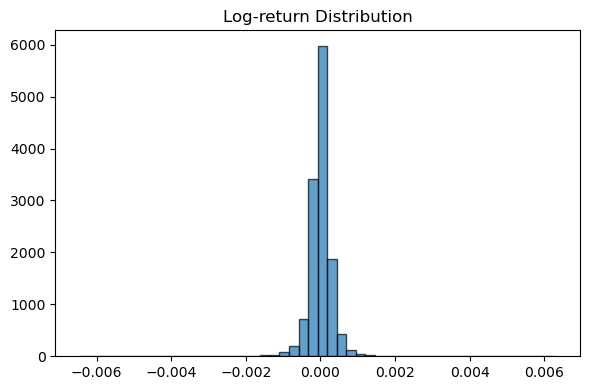

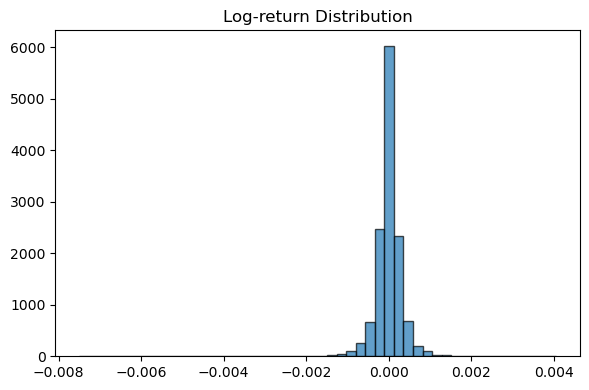

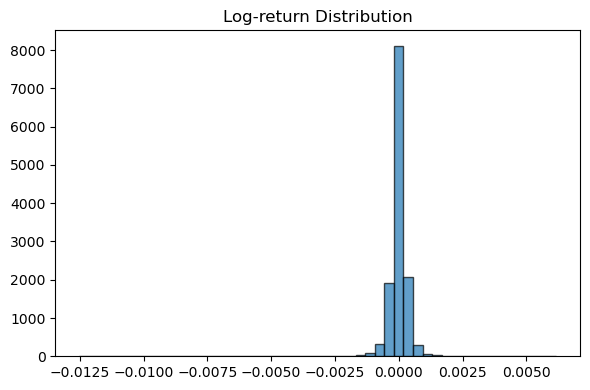

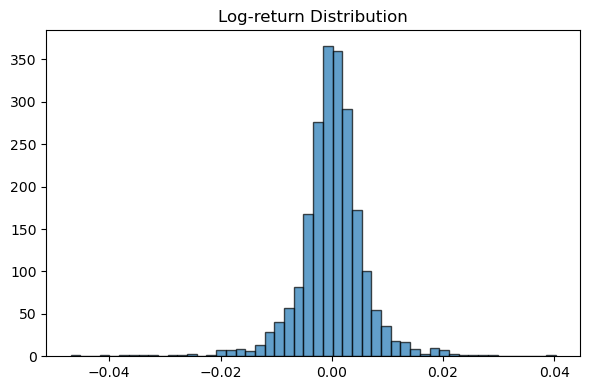

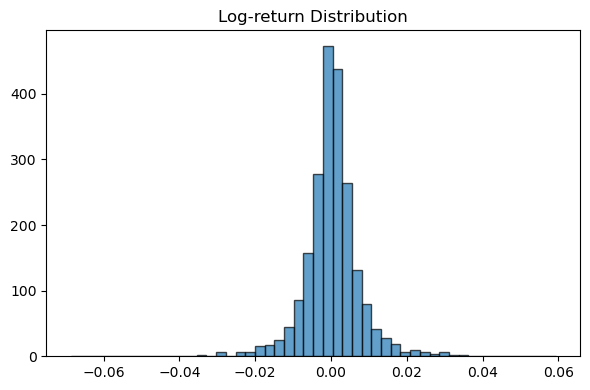

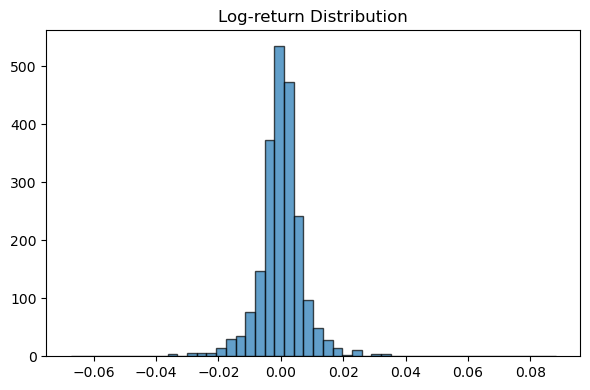

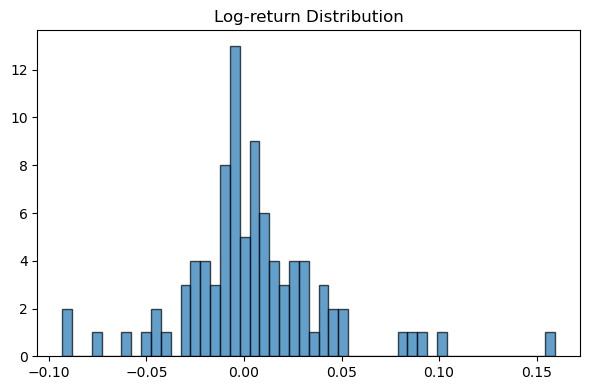

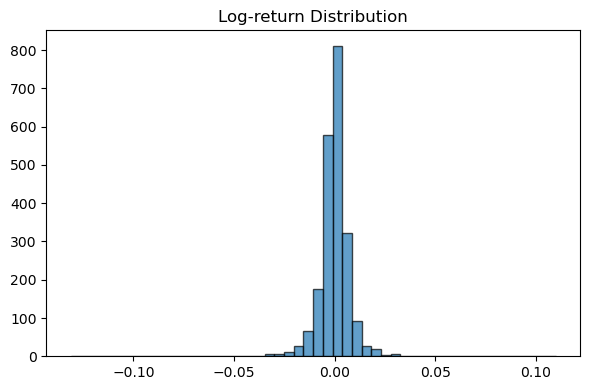

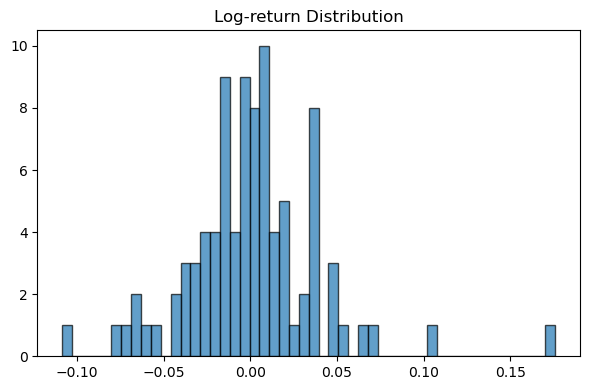

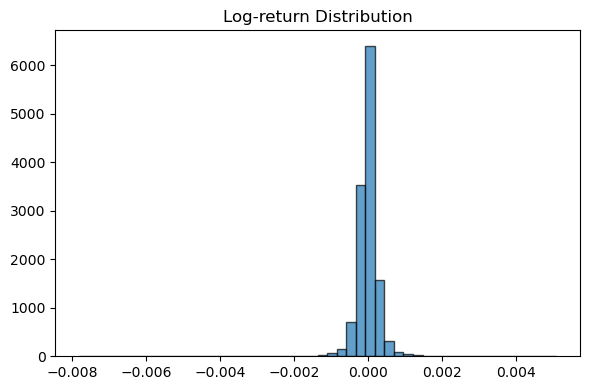

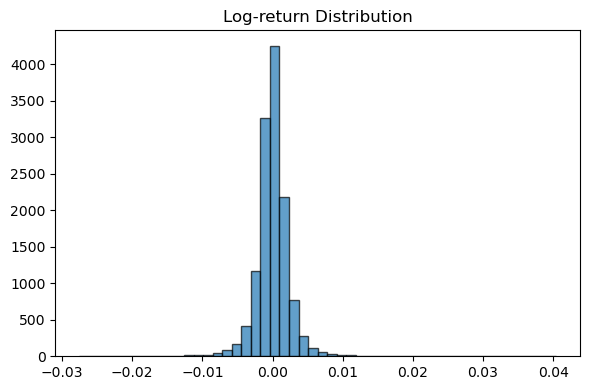

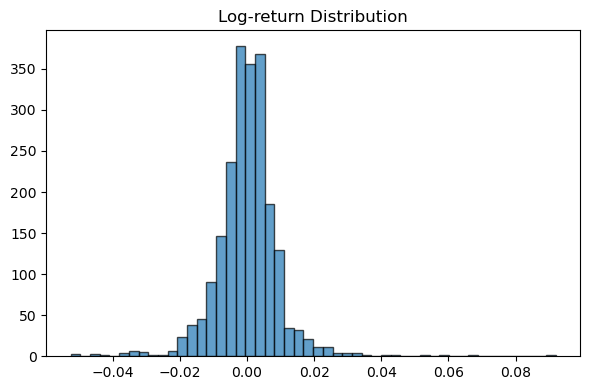

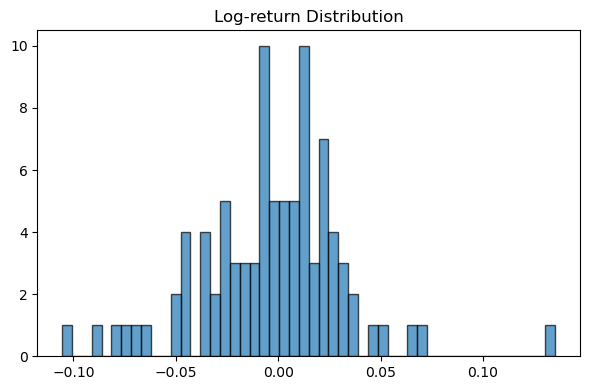

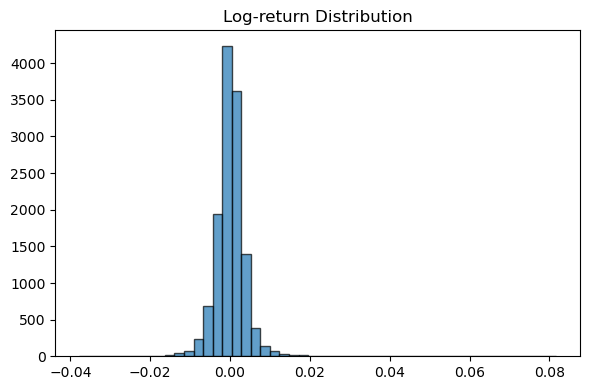

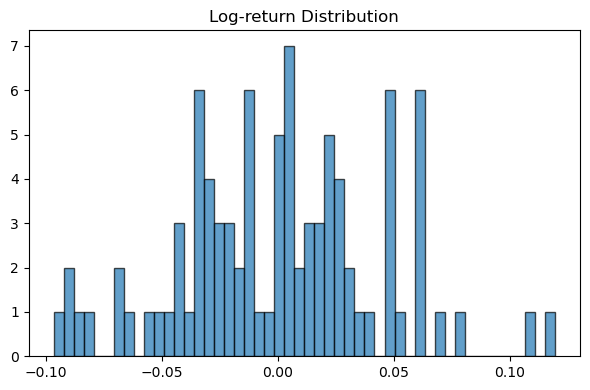

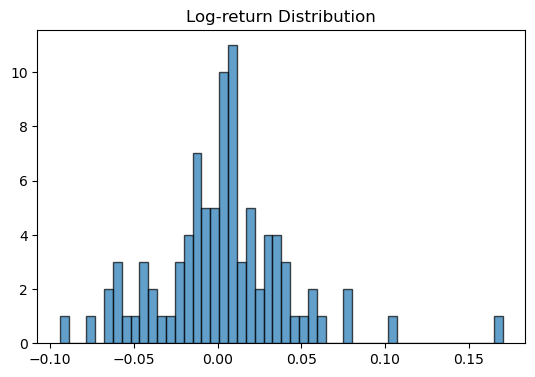

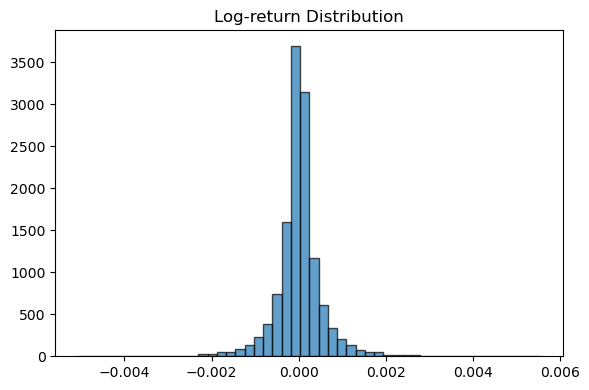

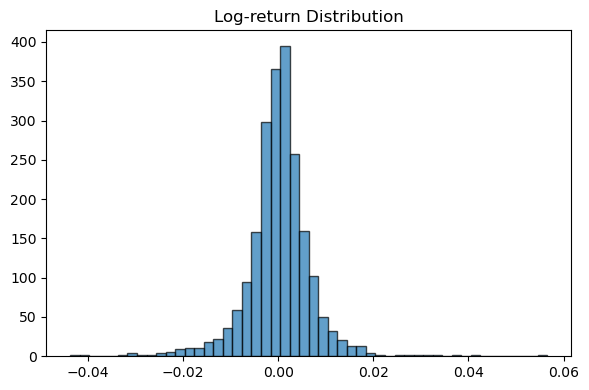

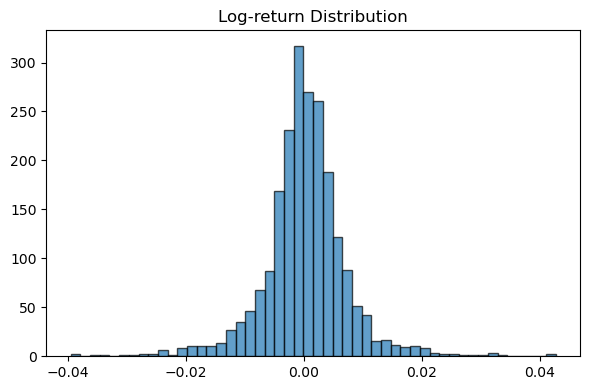

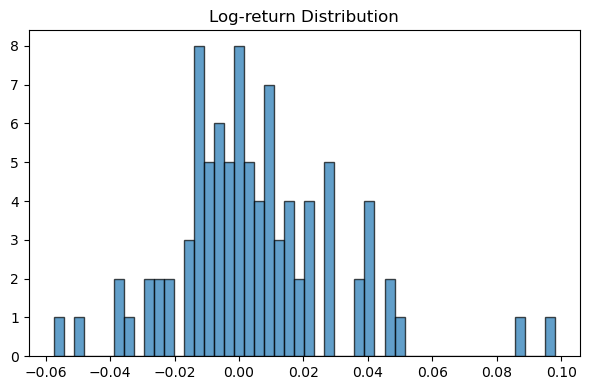

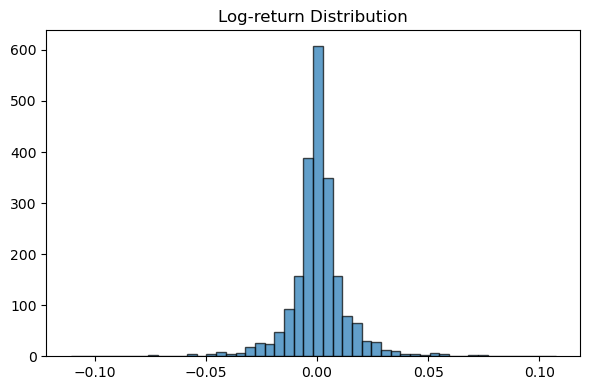

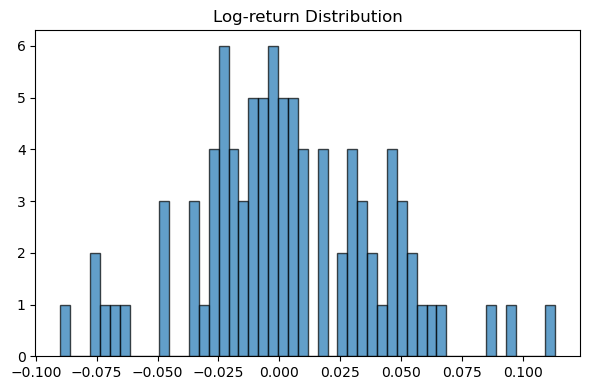

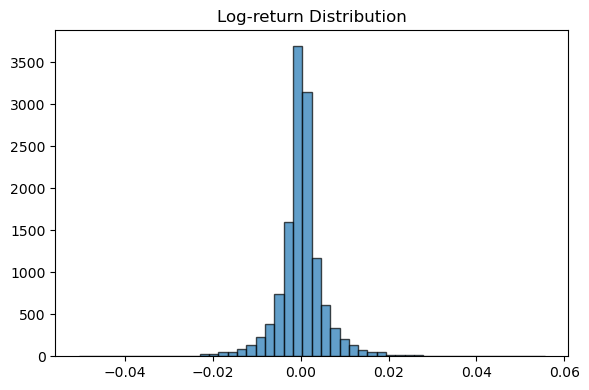

In [5]:
import warnings
# Suppress all warnings to keep output clean
warnings.filterwarnings('ignore')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# -----------------------------------------------------------------------------
# Configuration settings
# -----------------------------------------------------------------------------
DATA_ROOT = "data/resampled-v2"
SPLITS = [
    ("2024-06-01 (80/20)", "ratio"),
    ("2024-10-01",          "2024-10-01"),
    ("2025-01-01",          "2025-01-01"),
]
INTERVALS = ["1min", "10min", "1h", "1d"]
FREQ_MAP = {"1min": "T", "10min": "10T", "1h": "H", "1d": "D"}

# EDA settings
EDA_OUT = "results/eda_log_return"
MAX_LAGS = 20              # limit ACF/PACF lags
WINDOW_DAYS = 90           # number of days to keep
DOWNSAMPLE_MAP = {         # downsample mapping
    "1min": "10T"
}

# Parallel settings
N_JOBS = 4
PARALLEL_BACKEND = "threading"


def ensure_dir(path: str):
    """
    Create directory if not exists.
    """
    os.makedirs(path, exist_ok=True)


def load_train(split_dir: str, interval: str) -> pd.DataFrame:
    """
    Load training data for a specific split and interval.
    """
    df = pd.read_parquet(os.path.join(split_dir, f"train_{interval}.parquet"))
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df


def preprocess_log_return(df: pd.DataFrame, interval: str) -> pd.Series:
    """
    Compute log returns; apply downsampling and window truncation.
    """
    series = (
        df.set_index("timestamp")["close"]
          .asfreq(FREQ_MAP[interval])
          .dropna()
    )
    lr = np.log(series).diff().dropna()

    if interval in DOWNSAMPLE_MAP:
        lr = lr.resample(DOWNSAMPLE_MAP[interval]).mean().dropna()

    cutoff = lr.index.max() - pd.Timedelta(days=WINDOW_DAYS)
    return lr[lr.index >= cutoff]


def descriptive_stats(series: pd.Series) -> dict:
    """
    Compute basic descriptive statistics.
    """
    return {
        "mean": series.mean(),
        "std": series.std(),
        "skew": series.skew(),
        "kurtosis": series.kurtosis(),
        "min": series.min(),
        "25%": series.quantile(0.25),
        "50%": series.median(),
        "75%": series.quantile(0.75),
        "max": series.max(),
    }


def stationarity_tests(series: pd.Series) -> dict:
    """
    Perform ADF and KPSS unit root tests, return p-values.
    """
    adf_p = adfuller(series, autolag="AIC")[1]
    kpss_p = kpss(series, nlags="auto")[1]
    return {"adf_p": adf_p, "kpss_p": kpss_p}


def plot_and_save(series: pd.Series, out_dir: str):
    """
    Save histogram, ACF, and PACF plots.
    """
    ensure_dir(out_dir)
    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(series, bins=50, edgecolor='black', alpha=0.7)
    plt.title("Log-return Distribution")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "hist.png"))
    plt.close()

    # ACF
    fig, ax = plt.subplots(figsize=(6,4))
    plot_acf(series, lags=MAX_LAGS, ax=ax)
    ax.set_title(f"ACF (lags={MAX_LAGS})")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "acf.png"))
    plt.close(fig)

    # PACF
    fig, ax = plt.subplots(figsize=(6,4))
    plot_pacf(series, lags=MAX_LAGS, ax=ax, method='ywm')
    ax.set_title(f"PACF (lags={MAX_LAGS})")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "pacf.png"))
    plt.close(fig)


def eda_task(split_label: str, dirname: str, interval: str, coin: str):
    """
    Run EDA for one coin under a given split and interval.
    Prints all stats, saves CSV and plots.
    """
    # Ensure output directory exists
    safe_label = split_label.replace(" ", "_").replace("/", "-")
    out_dir = os.path.join(EDA_OUT, safe_label, interval, coin)
    ensure_dir(out_dir)

    try:
        # Load and preprocess
        split_dir = os.path.join(DATA_ROOT, dirname)
        df = load_train(split_dir, interval)
        df_coin = df[df.coin_id == coin]
        lr = preprocess_log_return(df_coin, interval)

        # Compute statistics
        stats = descriptive_stats(lr)
        tests = stationarity_tests(lr)
        stats.update(tests)

        # Print all results
        print(f"--- EDA Results: {split_label} | {interval} | {coin} ---")
        for k, v in stats.items():
            print(f"{k}: {v}")
        print("---------------------------------------------")

        # Save to CSV
        pd.DataFrame([stats]).to_csv(os.path.join(out_dir, "stats.csv"), index=False)

        # Generate plots
        plot_and_save(lr, out_dir)
        print(f"✅ Completed EDA for {split_label} | {interval} | {coin}\n")
    except Exception as e:
        import traceback
        print(f"❌ Error in EDA for {split_label} | {interval} | {coin}: {e}")
        traceback.print_exc()


def main():
    """
    Assemble tasks and run in parallel.
    """
    tasks = []
    for split_label, dirname in SPLITS:
        for interval in INTERVALS:
            df = load_train(os.path.join(DATA_ROOT, dirname), interval)
            for coin in df.coin_id.unique():
                tasks.append((split_label, dirname, interval, coin))

    start = time.time()
    Parallel(n_jobs=N_JOBS, backend=PARALLEL_BACKEND, prefer="threads")(
        delayed(eda_task)(*t) for t in tasks
    )
    print(f"All tasks completed in {time.time() - start:.1f} seconds.")


if __name__ == "__main__":
    main()